In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.random import SeedSequence

FIG_WIDTH = 4
FIG_HEIGHT = 4
TICK_FONTSIZE = 6
AXIS_FONTSIZE = 10

sns.set_theme(context='notebook', style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': AXIS_FONTSIZE,
    'xtick.labelsize': TICK_FONTSIZE,
    'ytick.labelsize': TICK_FONTSIZE,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
from IPython.display import HTML, display

from synthetic_data_generation import (
    generate_mean_vector,
    generate_sigma,
    generate_correlation_matrix,
    build_covariance_matrix,
    generate_true_performance_matrix,
    generate_observed_performance_data,
    build_covariance_matrix_task
)
from hierarchical_ranking.task_level_ranking import (
    pivot_scores_by_model,
    calc_paired_tests, 
    ranking_from_multiple_paired_tests, 
    calc_bootstrap_scores, 
    ranking_from_bootstrap_scores
)   
from hierarchical_ranking.ranking_measures import (
    calc_true_rank, 
    calc_coverage, 
    calc_interval_width,
    L_U_to_CI
)
from hierarchical_ranking.conformal_interval_aggregation import (
    merge_intervals_union, 
    merge_intervals_quantile
)
from hierarchical_ranking.plot_ranks import plot_ranks_intervals

In [2]:
# Initialize random seeds
seed = 2026
tasks_seed, obs_seed, boot_seed, boot_rank_seed = SeedSequence(seed).generate_state(4)

# True performance data

## Single configuration parameters

### Model effect

In [3]:
M = 30 # Number of models
mu_structure = 'increasing' # Mean structure
homoscedastic = True # Homoscedasticity, all models have the same variance
sigma_mean = 0.7 # Mean of the standard deviation, all models have the same standard deviation
rho = 0.5 # Correlation between models
block_size = 3 # Block size for the correlation matrix, between models
tie_proportion = 0.5 # Proportion of ties between models

mu = generate_mean_vector(M, structure=mu_structure)
sigma = generate_sigma(M, sigma_mean, homoscedastic=homoscedastic)
corr_matrix = generate_correlation_matrix(M, rho=rho, block_size=block_size)
cov_matrix = build_covariance_matrix(corr_matrix, sigma)

### Model-task effect

In [4]:
N = 20 # Number of tasks
task_effect = 0.1 # Task effect, how much the true performance of the models is different between tasks

# Model's true performance for each task
Theta = generate_true_performance_matrix(mu, cov_matrix, N, seed=tasks_seed)
# Calculate true rank intervals
true_ranks = {}
for b in range(N):
    task_name = f'task_{b}'
    true_scores_b = Theta[:, b]
    lowers, uppers = calc_true_rank(true_scores_b)
    true_ranks[task_name] = pd.Series(zip(lowers, uppers), index=[f'model_{i}' for i in range(M)])

true_ranks = pd.concat(true_ranks, axis=1)

# Add additional task-level covariance off the blocks, to add some noise to the observed values
cov_matrix_task = build_covariance_matrix_task(corr_matrix, sigma, task_effect=task_effect)

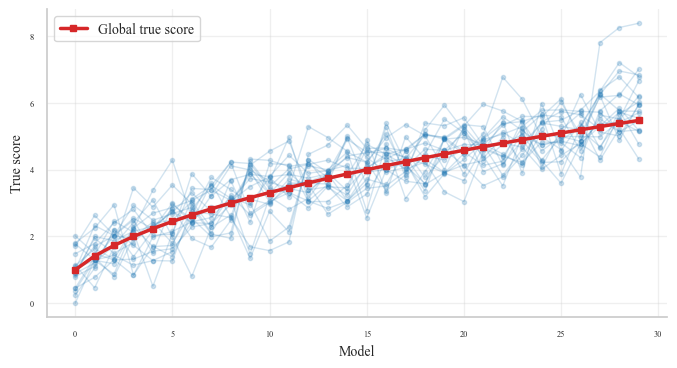

In [5]:
fig, ax = plt.subplots(figsize=(2 * FIG_WIDTH, FIG_HEIGHT))
for task in range(N):
    ax.plot(np.arange(M), Theta[:, task], marker='o', markersize=3, lw=1, alpha=0.2, color='tab:blue')
ax.plot(
    np.arange(M), mu, color='tab:red', lw=2.5, marker='s', markersize=5,
    label='Global true score', zorder=3)
ax.set(xlabel='Model', ylabel='True score')
ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
ax.legend(loc='upper left', fontsize=AXIS_FONTSIZE)
ax.grid(True, alpha=0.3);

# Observed performance data

Sampled around the per-task true scores.

In [6]:
n_base = 200 # Number of observations per-task (base values)
X = generate_observed_performance_data(Theta, cov_matrix_task, n_base, seed=obs_seed)

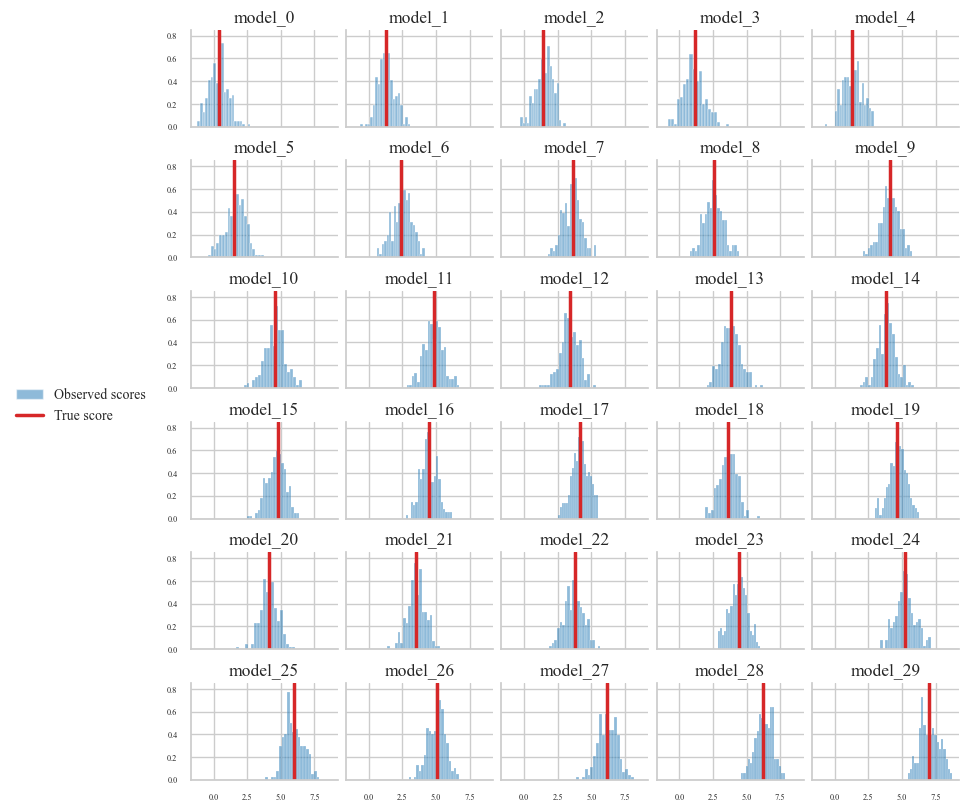

In [7]:
# Plot for one task and all models: distribution of observed scores vs true performance
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

task_idx = 0
task_name = f'task_{task_idx}'
X_task = X[(X['task'] == task_name)].reset_index(drop=True)

fig, axes = plt.subplots(6, M // 6, figsize=(2 * FIG_WIDTH, 2 * FIG_HEIGHT), 
                         constrained_layout=True, sharey=True, sharex=True)
for ax, j in zip(axes.flatten(), range(M)):
    scores = X_task.loc[X_task['model'] == f'model_{j}', 'score'].to_numpy()
    true_score = Theta[j, task_idx]
    sns.histplot(scores, stat='density', ax=ax, color='tab:blue', alpha=0.5, bins=20)
    ax.axvline(true_score, color='tab:red', lw=2.5)
    ax.set(xlabel='', ylabel='')
    ax.set_title(f'model_{j}')

fig.legend(
    handles=[
        Patch(facecolor='tab:blue', alpha=0.5, label='Observed scores'),
        Line2D([0], [0], color='tab:red', lw=2.5, label='True score'),
    ],
    loc='center left',
    bbox_to_anchor=(-0.2, 0.5),
    fontsize=AXIS_FONTSIZE,
    frameon=False
);

# Task-level ranking

## Comparison of FWER rank CIs and bootstrap rank CIs

In [8]:
marginal_correction = True
correction_method = 'holm'
alpha_tsk = 0.05
n_bootstrap = 200

In [9]:
all_ranks_intervals = {}
measurements_rows = []
tasks = X['task'].unique()
for task in tasks:
    all_ranks_intervals[task] = []
    base_values = pivot_scores_by_model(X[X['task'] == task], 'observation_id', 'model', 'score')
    
    # FWER rank CIs
    paired_test_res = calc_paired_tests(
        {'data': base_values}, 
        from_summary=False, 
        test_func_name='ttest', 
        alternative='less'
    )
    ranks = ranking_from_multiple_paired_tests(paired_test_res, alpha=alpha_tsk, 
                                               marginal_correction=marginal_correction, 
                                               correction_method=correction_method)
    true_ranks_task = true_ranks.loc[:,task].reindex(ranks.index)
    true_ranks_task.name = 'true_ranks'
    all_ranks_intervals[task].append(true_ranks_task)

    tuple_ranks = L_U_to_CI(ranks)
    tuple_ranks.name = 'fwer'
    all_ranks_intervals[task].append(tuple_ranks)
    measurements_rows.append({'task': task, 'method': 'fwer', 
                              'average_width': calc_interval_width(lowers=ranks['L'], uppers=ranks['U']),
                              'coverage': calc_coverage(ranks, true_ranks_task)[0]})

    # Bootstrap rank CIs
    bootstrap_scores = calc_bootstrap_scores(base_values, n_bootstrap=n_bootstrap, seed=boot_seed)
    bootstrap_intervals = ranking_from_bootstrap_scores(bootstrap_scores, alpha=alpha_tsk, seed=boot_rank_seed)
    tuple_bootstrap = L_U_to_CI(bootstrap_intervals)
    tuple_bootstrap.name = 'bootstrap'
    all_ranks_intervals[task].append(tuple_bootstrap)
    measurements_rows.append({'task': task, 'method': 'bootstrap', 
                              'average_width': calc_interval_width(lowers=bootstrap_intervals['L'], uppers=bootstrap_intervals['U']),
                              'coverage': calc_coverage(bootstrap_intervals, true_ranks_task)[0]})
    

In [10]:
# Interval width and marginal coverage
measurements = pd.DataFrame(measurements_rows)
fwer_df = measurements.query("method == 'fwer'").drop(columns='method').head(5)
bootstrap_df = measurements.query("method == 'bootstrap'").drop(columns='method').head(5)

display(HTML(
    '<div style="display:flex; gap:2rem; align-items:flex-start;">'
    f'<div><b>FWER</b>{fwer_df.to_html(index=False)}</div>'
    f'<div><b>Bootstrap</b>{bootstrap_df.to_html(index=False)}</div>'
    '</div>'
))

task,average_width,coverage
task_0,0.068966,1.0
task_1,0.077011,1.0
task_2,0.091954,1.0
task_3,0.101149,1.0
task_4,0.089655,1.0
task,average_width,coverage
task_0,0.042529,1.0
task_1,0.043678,1.0
task_2,0.057471,1.0
task_3,0.073563,1.0


# Leaderboard-level ranking

In [11]:
alpha_ldb = 0.5
ranks_collection = pd.DataFrame({
    task: next(s for s in all_ranks_intervals[task] if s.name == 'fwer')
    for task in tasks
})

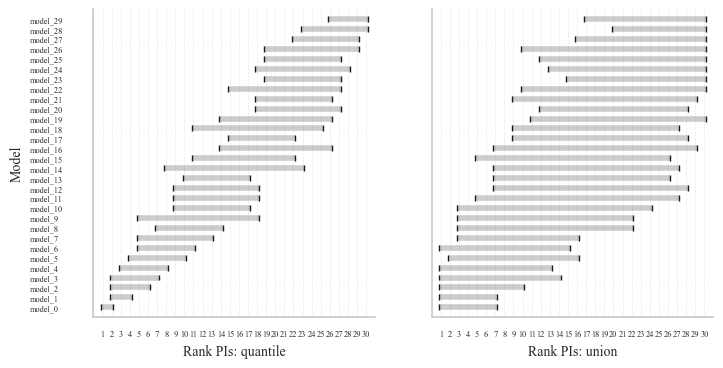

In [12]:
fixed_model_order = [f'model_{i}' for i in range(M)]
fig, axs = plt.subplots(1, 2, figsize=(2 * FIG_WIDTH, FIG_HEIGHT))
quantile_intervals = merge_intervals_quantile(ranks_collection, alpha_ldb=alpha_ldb)
plot_ranks_intervals(
    quantile_intervals,
    ax=axs[0],
    fixed_order=fixed_model_order,
    labels_fontsize=TICK_FONTSIZE,
    axis_fontsize=AXIS_FONTSIZE,
    xlabel='Rank PIs: quantile',
    align_labels='left',
    linewidth=4,
)
union_intervals = merge_intervals_union(ranks_collection)
plot_ranks_intervals(
    union_intervals,
    ax=axs[1],
    fixed_order=fixed_model_order,
    labels_fontsize=TICK_FONTSIZE,
    axis_fontsize=AXIS_FONTSIZE,
    ylabel='',
    xlabel='Rank PIs: union',
    show_yticklabels=False,
    linewidth=4,
);